# MiBiReMo Example: Field model tracer test in a layered aquifer

The tracer test of the example field_tracer_test (one extraction well EXT_1 and four injection wells INJ_1–4 at the
corners of a square, 4 m from EXT_1) is repeated in a layered aquifer made of three hydrostratigraphic units: an upper
sandy unit, a middle silty unit, and a lower unit of low permeability. The units are horizontal.
The wells are screened over the upper and middle units, from 95.5 to 90.5 m a.s.l. A monitoring well with two sampling
levels (MON_1 in the upper unit, MON_2 in the middle unit) lies between INJ_4 and EXT_1.

The lateral boundary is a general-head boundary (GHB): water enters and leaves the domain in proportion to the
difference between the head of the regional groundwater flow and the head in the boundary cells.

The results are compared with those of a homogeneous single-layer aquifer with the same transmissivity over the
screened interval. A tracer is injected during the first day at a concentration of 1.0 g m⁻³.

MODFLOW 6 is required for running this script. Please install it using: get-modflow :python --subset mf6,libmf6

In [1]:
from dataclasses import replace
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import mibiremo as mb

HOUR, DAY = 3600.0, 86400.0
OUTPUT = (Path(__file__).parent if "__file__" in globals() else Path()) / "output"  # next to this script or notebook

## Wells

The extraction and injection wells are those of field_tracer_test. The two monitoring wells are at the same location,
with short screens in the upper (MON_1) and middle (MON_2) units. They have no flow rate.

In [2]:
extraction = mb.Well(
    "EXT_1", x=0.0, y=0.0, well_top=96.3, well_bottom=90.5, diameter=0.1, screen_top=95.5, screen_bottom=90.5
)
injection = mb.array_radial(replace(extraction, name="INJ"), n_wells=4, radius=4.0)
monitoring = [
    mb.Well(
        "MON_1", x=-2.0, y=0.0, well_top=96.3, well_bottom=94.0, diameter=0.05, screen_top=95.0, screen_bottom=94.0
    ),
    mb.Well(
        "MON_2", x=-2.0, y=0.0, well_top=96.3, well_bottom=91.5, diameter=0.05, screen_top=92.5, screen_bottom=91.5
    ),
]
wells = [extraction, *injection, *monitoring]

Q = 2.9e-5  # flow rate of each injection well [m3 s-1], 2.5 m3/d
flow_rates = {"EXT_1": -4 * Q} | {w.name: Q for w in injection}

## Model setup

Both models share the wells, the regional groundwater flow, the boundary, the tracer, and the time steps.

`boundary_conductance` sets a general-head boundary with conductance C [m² s⁻¹] in each lateral boundary cell, with
the head of the regional groundwater flow as external head; without it, the heads of the boundary cells are fixed.

In [3]:
common = dict(
    wells=wells,
    flow_rates=flow_rates,
    domain_size=(80.0, 80.0),
    porosity=0.25,
    reference_head=93.7,
    regional_hydraulic_gradient=0.01,
    regional_flow_azimuth=90.0,
    boundary_conductance=1e-4,
    tracer_concentration=[(0.0, 1.0), (DAY, 0.0)],
    grid_spacing=4.0,
    grid_spacing_at_wells=0.5,
    simulation_time=20 * DAY,
    time_step=[(0.0, HOUR), (DAY, 4 * HOUR)],
)

The layered aquifer is made of hydrostratigraphic units: `layer_bottom` is a list with the bottom elevation of each
unit, from top to bottom. The number of layers, the hydraulic conductivity, the vertical anisotropy, and the porosity
are either one value for all units or a list with one value per unit. Each unit is divided into layers of equal
thickness.

Elevations are constant, as here (horizontal units), or a function z(x, y) of the coordinates, e.g. for dipping units.
Elevations measured at a few points can be interpolated with scipy, e.g.
`scipy.interpolate.NearestNDInterpolator(points, z)`.

In [4]:
layered = mb.FieldModel(
    workspace=OUTPUT / "field_layered_model" / "layered",
    top=95.5,
    layer_bottom=[93.5, 90.5, 87.0],  # upper, middle, and lower unit
    n_layers=[4, 3, 1],
    hydraulic_conductivity=[5e-5, 5e-6, 1e-7],  # K [m s-1]
    vertical_anisotropy=0.1,  # Kz/K, all units
    **common,
)

The homogeneous aquifer is the screened interval, with the transmissivity-weighted mean hydraulic conductivity of the
upper (2 m) and middle (3 m) units. The lower unit carries almost no flow.

In [5]:
conductivity = (5e-5 * 2.0 + 5e-6 * 3.0) / 5.0
homogeneous = mb.FieldModel(
    workspace=OUTPUT / "field_layered_model" / "homogeneous",
    top=95.5,
    layer_bottom=90.5,
    hydraulic_conductivity=conductivity,
    **common,
)
print(f"Hydraulic conductivity of the homogeneous aquifer: {conductivity:.1e} m/s")

Hydraulic conductivity of the homogeneous aquifer: 2.3e-05 m/s


The cross section along the groundwater flow through EXT_1 shows the hydraulic conductivity of the layers and the
well screens. The model is built (not run) to get the grid and the flopy simulation.

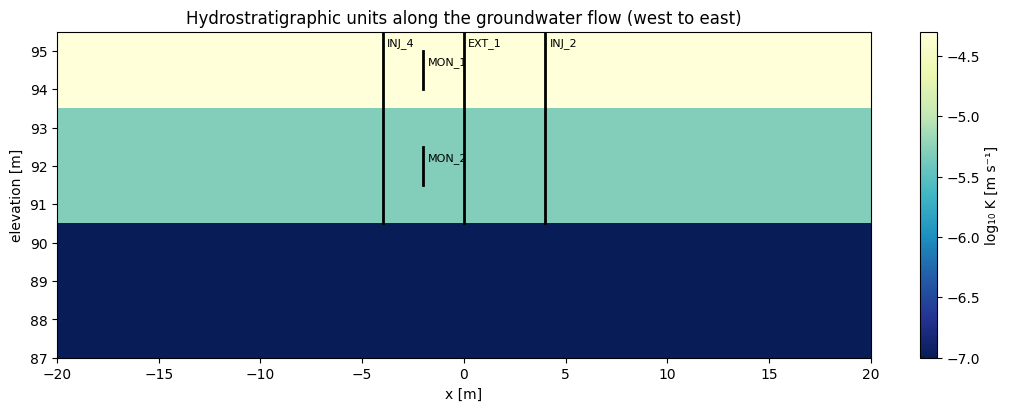

In [6]:
layered.build()
fig, ax = plt.subplots(figsize=(10, 4), layout="constrained")
section = [(-20.0, 0.0), (20.0, 0.0)]
k = layered.simulation.get_model("gwf").npf.k.array
mb.plotting.cross_section(layered, np.log10(k), section, label="log₁₀ K [m s⁻¹]", ax=ax, cmap="YlGnBu_r")
ax.set_title("Hydrostratigraphic units along the groundwater flow (west to east)")
plt.show()

## Simulation

In [7]:
layered.run()
homogeneous.run()
for name, model in [("Layered", layered), ("Homogeneous", homogeneous)]:
    print(f"{name}: grid {model.grid.nrow} rows x {model.grid.ncol} columns x {model.grid.nlay} layers")

Layered: grid 59 rows x 59 columns x 8 layers
Homogeneous: grid 59 rows x 59 columns x 1 layers


## Hydraulic head

`well_head` returns the head of a well, the mean over its screened cells weighted by K b. With the same transmissivity,
the two models give almost the same drawdown at the extraction well.

In [8]:
for name, model in [("layered", layered), ("homogeneous", homogeneous)]:
    print(f"Head at EXT_1, {name} aquifer: {model.well_head('EXT_1')['head'].iloc[-1]:.2f} m")

Head at EXT_1, layered aquifer: 93.11 m
Head at EXT_1, homogeneous aquifer: 93.11 m


## Tracer

In the layered aquifer most of the water flows through the upper unit, so the tracer moves faster there, while it
spreads slowly in the middle unit. In the homogeneous aquifer the tracer moves at the same velocity over the whole
screened interval.

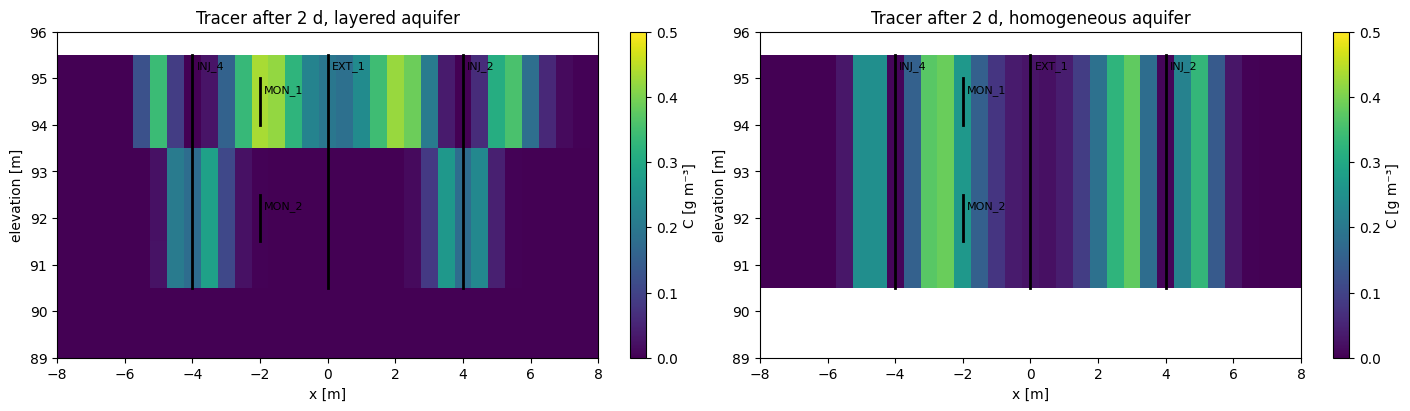

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4), layout="constrained")
for ax, (name, model) in zip(axes, [("layered", layered), ("homogeneous", homogeneous)]):
    mb.plotting.cross_section(model, model.concentration(2 * DAY), section, label="C [g m⁻³]", ax=ax, vmin=0, vmax=0.5)
    ax.set(xlim=(-8, 8), ylim=(89, 96), title=f"Tracer after 2 d, {name} aquifer")
plt.show()

## Breakthrough curves

In the layered aquifer most of the tracer reaches EXT_1 through the upper unit, so the peak is earlier and higher,
while the slow middle unit retains part of the tracer longer. The monitoring wells show the fast breakthrough in the
upper unit (MON_1) and the slow one in the middle unit (MON_2); in the single-layer model both levels sample the same
cell.

Layered aquifer: peak C at EXT_1 = 0.194 g/m3 at 2.5 d, tracer mass recovered after 20 d: 77%
Homogeneous aquifer: peak C at EXT_1 = 0.111 g/m3 at 4.7 d, tracer mass recovered after 20 d: 79%


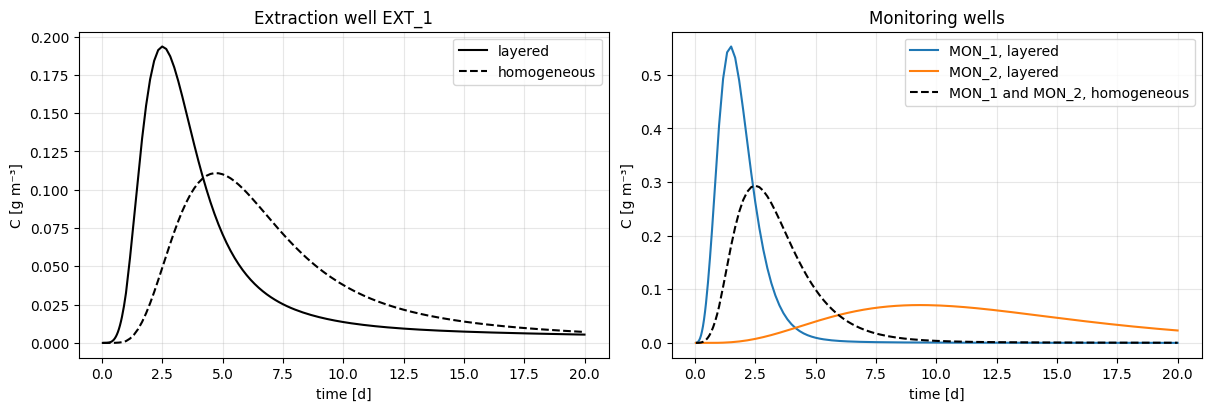

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), layout="constrained")
for (name, model), style in zip([("layered", layered), ("homogeneous", homogeneous)], ["-", "--"]):
    curve = model.well_concentration("EXT_1")
    balance = model.mass_balance()
    recovered = balance["extracted"].iloc[-1] / balance["injected"].iloc[-1]
    peak = curve.loc[curve["concentration"].idxmax()]
    print(
        f"{name.capitalize()} aquifer: peak C at EXT_1 = {peak['concentration']:.3f} g/m3 at "
        f"{peak['time'] / DAY:.1f} d, tracer mass recovered after 20 d: {recovered:.0%}"
    )
    axes[0].plot(curve["time"] / DAY, curve["concentration"], "k" + style, label=name)
for name, color in [("MON_1", "tab:blue"), ("MON_2", "tab:orange")]:
    curve = layered.well_concentration(name)
    axes[1].plot(curve["time"] / DAY, curve["concentration"], color=color, label=f"{name}, layered")
curve = homogeneous.well_concentration("MON_1")
axes[1].plot(curve["time"] / DAY, curve["concentration"], "k--", label="MON_1 and MON_2, homogeneous")
axes[0].set(xlabel="time [d]", ylabel="C [g m⁻³]", title="Extraction well EXT_1")
axes[1].set(xlabel="time [d]", ylabel="C [g m⁻³]", title="Monitoring wells")
for ax in axes:
    ax.grid(alpha=0.3)
    ax.legend()
plt.show()

The domain is centred on the pumped wells by default; `domain_centre` places it elsewhere, e.g. to match the extent of
an existing model.